# scMAGCL

**scMAGCL** (Multi-level multi-attention based graph contrastive learning) learns a low-dimensional
representation of single-cell RNA-seq profiles. A shared autoencoder encodes each cell and a gene-masked
copy of it; at three depths (latent space, decoder hidden layer, reconstruction), self-attention builds
intra-cell graphs within each view and cross-attention builds inter-cell graphs between the views. A graph
contrastive loss on these graphs, plus a reconstruction loss, trains the model.

This notebook demonstrates the full pipeline on the **Adam** dataset (mouse kidney, 3,660 cells, 8 cell types):

1. Load the preprocessed `data/adam.h5` file.
2. Train the scMAGCL model.
3. Cluster the learned latent space with K-Means and report **ACC, NMI, ARI** and **training time**.
4. Visualize the latent space with **UMAP**, colored by true cell types and predicted clusters.

## 1. Imports & Setup

In [1]:
import h5py
import numpy as np
import pandas as pd
import torch
import umap
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from scipy.optimize import linear_sum_assignment
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from torch.utils.data import DataLoader

# scMAGCL project modules
from config import get_config
from utils import setup_seed, scRNASeqDataset, evaluate_clustering
from model import scMAGCL
from main import load_dataset, train_model

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

In [2]:
# ---- Configuration ----
DATA_PATH = 'data/adam.h5'

config = get_config()
# Adam has 3,660 cells, so it uses batch size 128 (the setting for datasets with < 4,000 cells).
config['batch_size'] = 128
# Feel free to lower `epochs` for a quicker demo; the default reproduces the paper setup.
config['epochs'] = 200

setup_seed(config['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print('Configuration:')
for k, v in config.items():
    print(f'  {k}: {v}')

Using device: cuda
Configuration:
  mask_prob: 0.25
  lambda_recon: 1.0
  lambda_contrast: 1.0
  alpha: 0.55
  beta: 0.4
  temperature: 0.5
  lr: 0.001
  weight_decay: 0.0001
  epochs: 200
  batch_size: 128
  grad_clip: 1.0
  test_size: 0.2
  seed: 42
  save_dir: results


## 2. Load the Adam Dataset

The `.h5` file holds the expression matrix `X` (cells x genes) and the integer cell-type labels `Y`;
the cell-type names are stored in `Y.attrs['classes']`. The number of clusters is the number of
cell types in `Y`, exactly as in `main.py`.

In [3]:
X_all, y_all = load_dataset(DATA_PATH)
with h5py.File(DATA_PATH, 'r') as f:
    class_names = np.array(f['Y'].attrs['classes'], dtype=str)

n_clusters = len(np.unique(y_all))

print(f'Expression matrix : {X_all.shape[0]} cells x {X_all.shape[1]} genes')
print(f'Number of clusters: {n_clusters}')
print('\nCell type distribution:')
print(pd.Series(class_names[y_all]).value_counts().to_string())

Expression matrix : 3660 cells x 2500 genes
Number of clusters: 8

Cell type distribution:
Ureteric bud     629
PT               617
LH               516
CM               513
Stromal          463
Distal tubule    396
ED               302
Podocytes        224


## 3. Train / Test Split & DataLoaders

80% of the cells are used for training and 20% are held out for testing, stratified by cell type.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=config['test_size'], random_state=config['seed'], stratify=y_all
)

train_loader = DataLoader(scRNASeqDataset(X_train, y_train),
                          batch_size=config['batch_size'], shuffle=True)
test_loader = DataLoader(scRNASeqDataset(X_test, y_test),
                         batch_size=config['batch_size'], shuffle=False)

print(f'Train cells: {len(X_train)} | Test cells: {len(X_test)}')

Train cells: 2928 | Test cells: 732


## 4. Build the Model

In [5]:
model = scMAGCL(input_dim=X_all.shape[1]).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')

Model parameters: 15,758,104


## 5. Train the Model

In every batch, a copy of the cells with 25% of genes masked is created, and both views pass through the
shared autoencoder. The loss is the reconstruction error plus the graph contrastive loss at the three
depths. After each epoch the test cells are embedded; `train_model` returns the test-set embedding from the
epoch with the lowest test reconstruction loss, the corresponding labels, and the total training time.

In [6]:
best_latent, best_labels, training_time = train_model(
    model, train_loader, test_loader, config, device
)
print(f'\nLatent representation shape: {best_latent.shape}')


Training scMAGCL


Epoch 10/200: Total Loss=10.1527 (Recon=9.6789, Contrast=0.4738), Test Loss=2.5258


Epoch 20/200: Total Loss=9.7012 (Recon=9.3099, Contrast=0.3914), Test Loss=2.4490


Epoch 30/200: Total Loss=9.5206 (Recon=9.1668, Contrast=0.3538), Test Loss=2.4180


Epoch 40/200: Total Loss=9.4094 (Recon=9.0795, Contrast=0.3299), Test Loss=2.4025


...

Epoch 160/200: Total Loss=8.9593 (Recon=8.7297, Contrast=0.2297), Test Loss=2.3447


Epoch 170/200: Total Loss=8.9499 (Recon=8.7191, Contrast=0.2308), Test Loss=2.3436


Epoch 180/200: Total Loss=8.9437 (Recon=8.7144, Contrast=0.2293), Test Loss=2.3431


Epoch 190/200: Total Loss=8.9397 (Recon=8.7097, Contrast=0.2301), Test Loss=2.3430


Epoch 200/200: Total Loss=8.9371 (Recon=8.7099, Contrast=0.2272), Test Loss=2.3428

Training completed in 163.33 seconds

Latent representation shape: (732, 128)


## 6. Evaluate: ACC, NMI, ARI & Training Time

K-Means is run on the 128-dimensional latent space of the test cells, and clustering quality is measured
against the ground-truth cell types.

In [7]:
kmeans = KMeans(n_clusters=n_clusters, random_state=config['seed'], n_init=20)
pred_labels = kmeans.fit_predict(best_latent)

acc, nmi, ari = evaluate_clustering(best_labels, pred_labels)

results = pd.DataFrame({
    'Metric': ['Clustering Accuracy (ACC)', 'NMI', 'ARI', 'Training time (s)'],
    'Value':  [f'{acc:.4f}', f'{nmi:.4f}', f'{ari:.4f}', f'{training_time:.2f}'],
})
print('=' * 45)
print(f'   scMAGCL results on Adam ({n_clusters} clusters)')
print('=' * 45)
results

   scMAGCL results on Adam (8 clusters)


,Metric,Value
0,Clustering Accuracy (ACC),0.9481
1,NMI,0.8990
2,ARI,0.8958
3,Training time (s),163.33


## 7. UMAP Visualization of the Latent Space

The latent embeddings of the test cells are projected to 2D with UMAP. On the left, cells are colored by
their **true cell type**. On the right, each **predicted K-Means cluster** is colored by the cell type it is
matched to (the same one-to-one matching used to compute ACC), so a cell whose color differs between the
two panels was assigned to the wrong cluster.

In [8]:
reducer = umap.UMAP(n_components=2, random_state=config['seed'], n_jobs=1)
embedding_2d = reducer.fit_transform(best_latent)
print(f'UMAP embedding shape: {embedding_2d.shape}')

UMAP embedding shape: (732, 2)


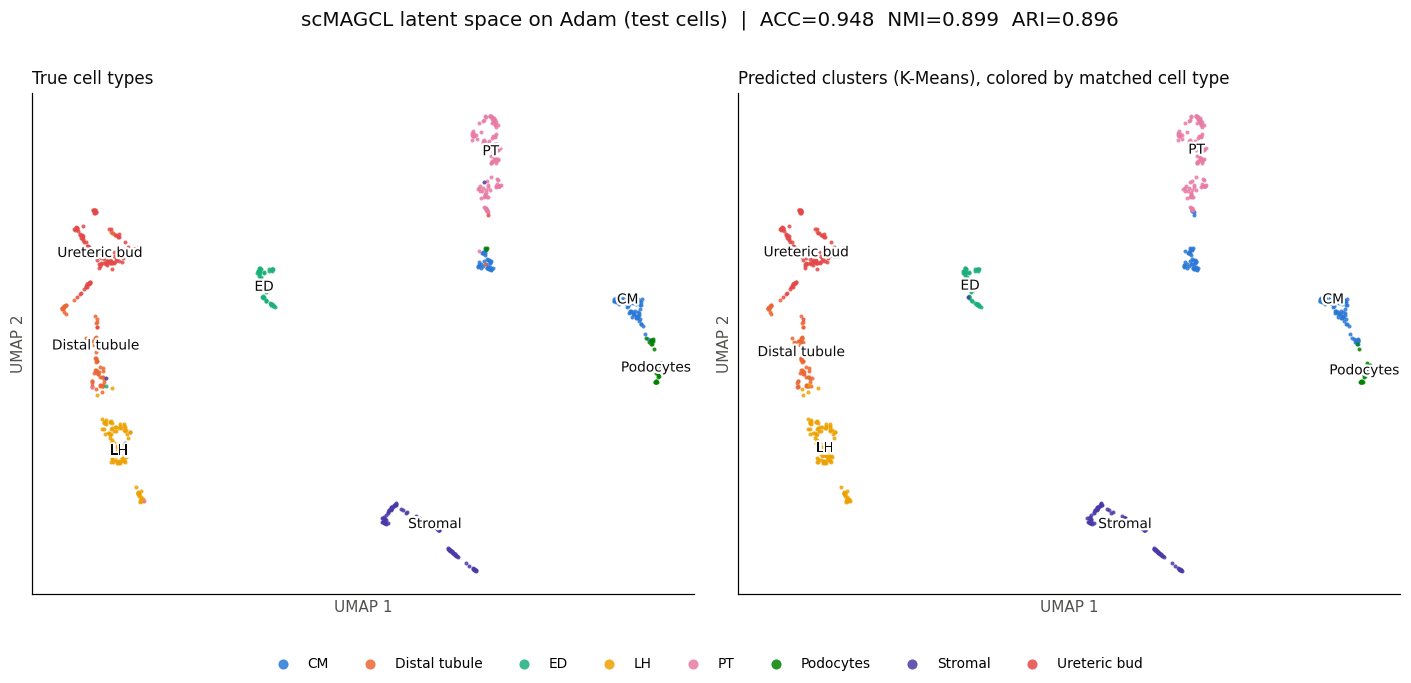

In [9]:
# Match each predicted cluster to a cell type (Hungarian algorithm, as in the ACC metric)
contingency = np.zeros((n_clusters, n_clusters), dtype=np.int64)
np.add.at(contingency, (pred_labels, best_labels), 1)
cluster_idx, type_idx = linear_sum_assignment(-contingency)
cluster_to_type = np.empty(n_clusters, dtype=int)
cluster_to_type[cluster_idx] = type_idx
pred_as_type = cluster_to_type[pred_labels]

# Fixed-order categorical palette, one color per cell type
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
           '#e87ba4', '#008300', '#4a3aa7', '#e34948']
colors = PALETTE if n_clusters <= len(PALETTE) else list(plt.cm.tab20.colors)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2), sharex=True, sharey=True)
panels = [(best_labels, 'True cell types'),
          (pred_as_type, 'Predicted clusters (K-Means), colored by matched cell type')]

for ax, (labels, title) in zip(axes, panels):
    for t in range(n_clusters):
        m = labels == t
        ax.scatter(embedding_2d[m, 0], embedding_2d[m, 1], s=7, color=colors[t],
                   alpha=0.85, linewidths=0, label=class_names[t])
        if m.any():
            # Name each group at its median position
            cx, cy = np.median(embedding_2d[m], axis=0)
            ax.text(cx, cy, class_names[t], fontsize=9, ha='center', va='center',
                    color='#0b0b0b', path_effects=[pe.withStroke(linewidth=3, foreground='white')])
    ax.set_title(title, loc='left', fontsize=11, color='#0b0b0b')
    ax.set_xlabel('UMAP 1', color='#52514e')
    ax.set_ylabel('UMAP 2', color='#52514e')
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)

handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, loc='lower center', ncol=min(n_clusters, 8),
           markerscale=2.5, frameon=False, fontsize=9)
fig.suptitle(f'scMAGCL latent space on Adam (test cells)  |  '
             f'ACC={acc:.3f}  NMI={nmi:.3f}  ARI={ari:.3f}', fontsize=13, color='#0b0b0b')
plt.tight_layout(rect=[0, 0.07, 1, 0.97])
plt.show()